# Time Series Data

In [9]:
import sys
!{sys.executable} -m pip install yfinance statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.6 MB/s  0:00:06 1.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Users/pawankumar/ai_anomaly_project/.venv/bin/python -m pip install --upgrade pip


In [10]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2024-01-01')
stock_data.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873962,181.040748,178.855492,180.111267,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500
2024-01-09,183.067764,183.077647,180.684735,181.861418,42841800
2024-01-10,184.106018,184.313659,181.861421,182.286616,46792900
2024-01-11,183.512741,184.956406,181.564790,184.452105,49128400
2024-01-12,183.839035,184.649864,183.117210,183.977467,40477800


# A) Classical Time Series Decomposition

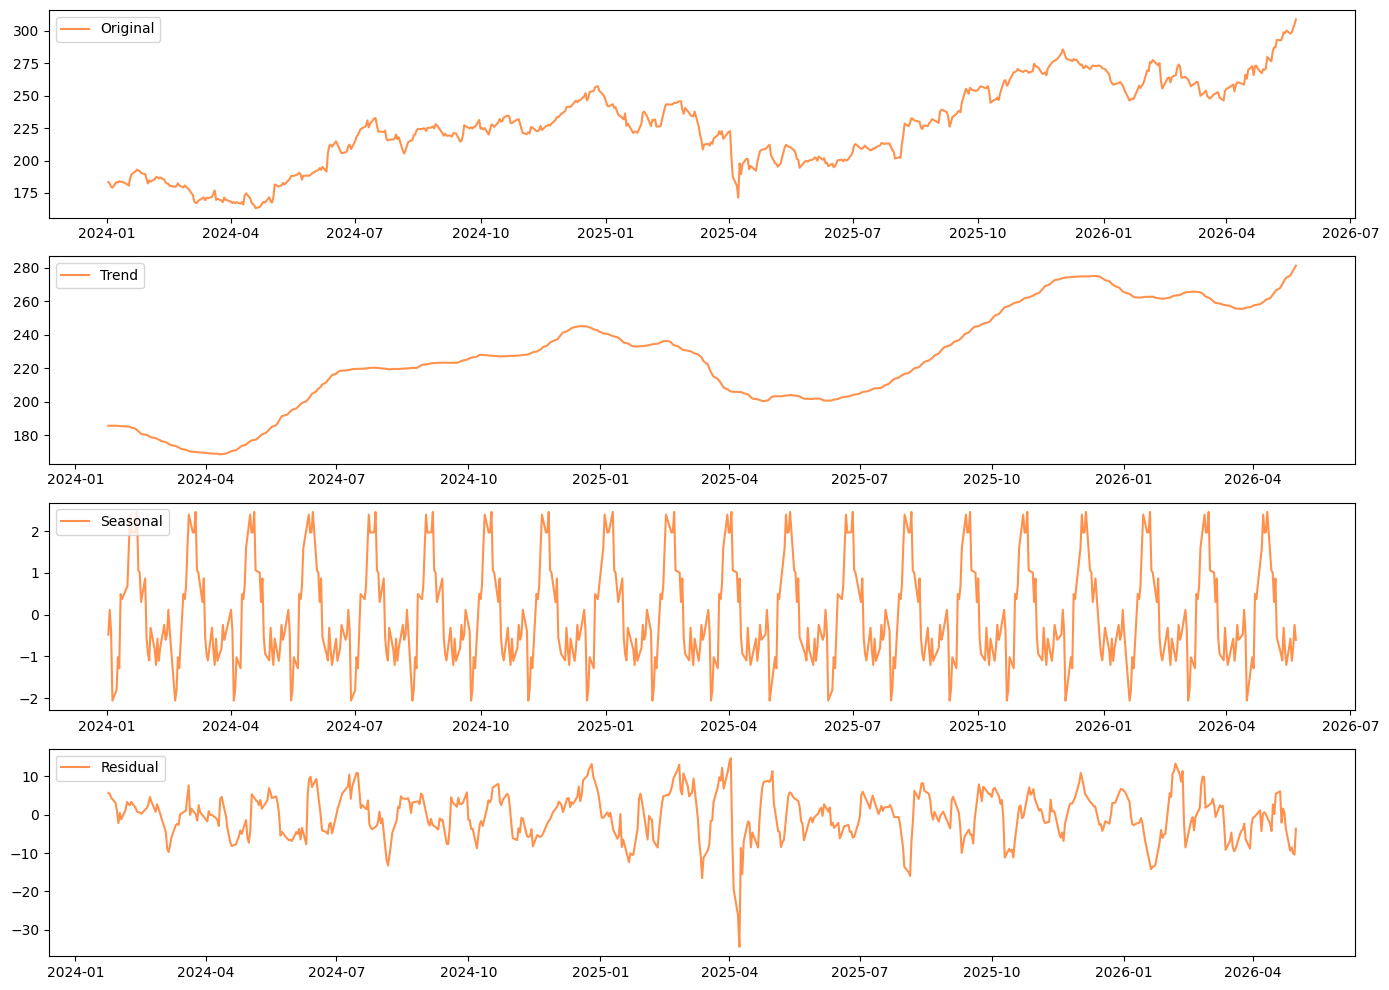

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend_additive, label='Trend', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual_additive, label='Residual', color = '#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# B) STL Time Series Decomposition

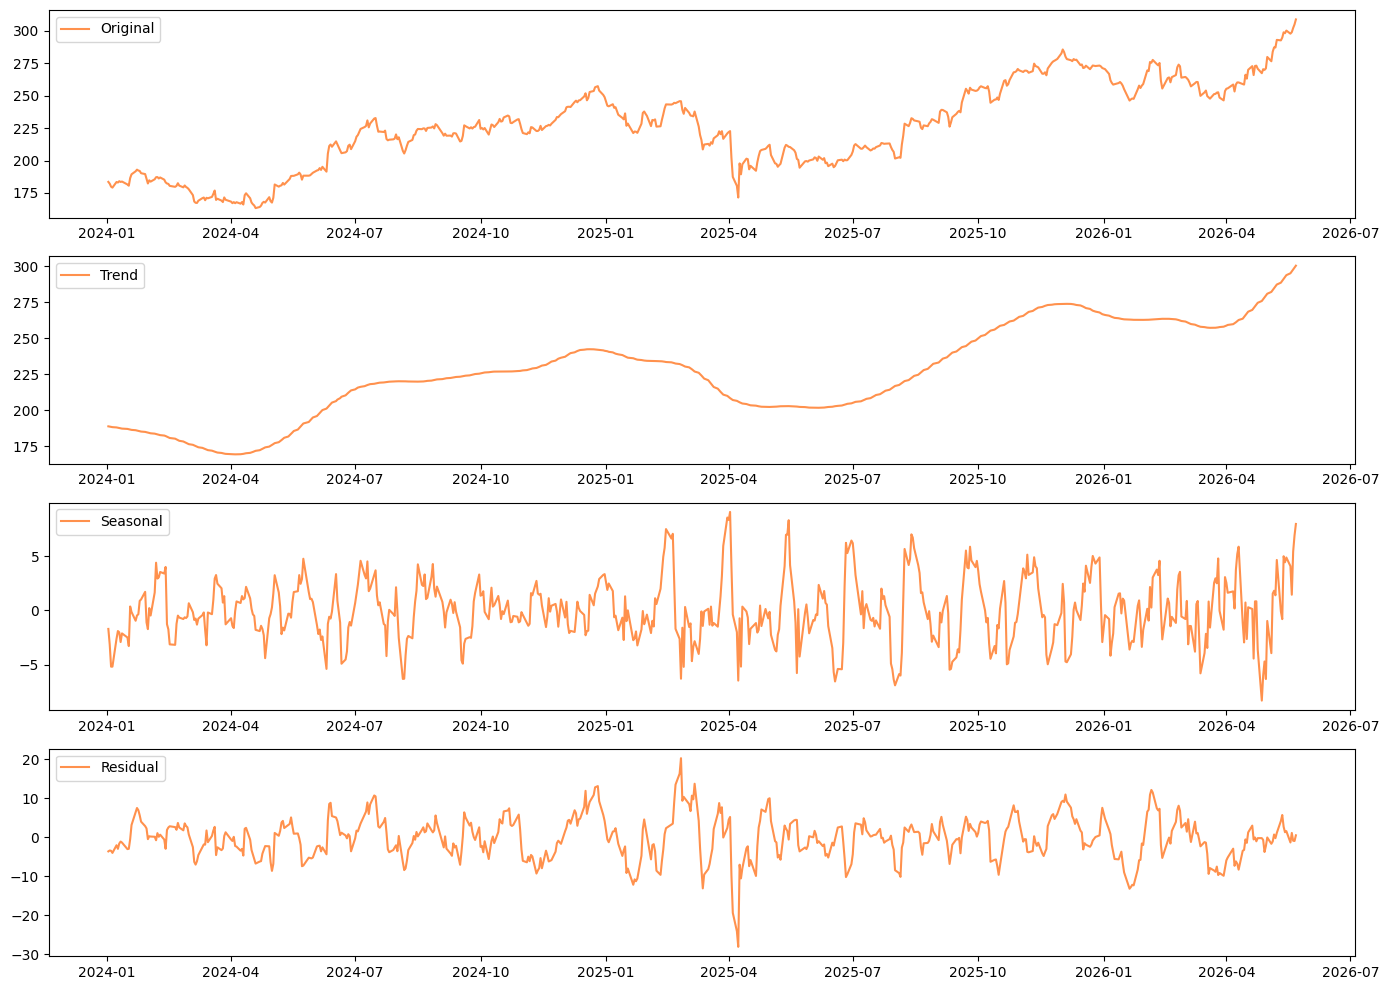

In [12]:
from statsmodels.tsa.seasonal import STL

# Perform STL decomposition
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

# Plot the decomposition components
plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(result.observed, label='Original', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(result.trend, label='Trend', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color = '#FF914D')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(result.resid, label='Residual', color = '#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()